In [12]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2


[autoreload of meteor.tv failed: Traceback (most recent call last):
  File "/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 283, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 483, in superreload
    module = reload(module)
  File "/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1026, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/Users/sbielfel/anaconda3/envs/fml/lib/python3.13/site-packages/meteor/tv.py", line 14, in <module>
    from .scale import ScaleMode, scale_maps
ImportError: canno

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

from dataset_configs import get_all_configs
from dataset_configs import get_some_configs
from vacuum_plots_many import loader, loader_double





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
from estimation import _calculate_statistics, _analyze_threshold_trends,plot_extrapolation_estimate_new
import logging 
logger = setup_logger()
logger.setLevel(logging.WARNING)
# logger.setLevel(logging.INFO)


In [15]:
from estimation import _calculate_statistics, _analyze_threshold_trends,plot_extrapolation_estimate_new
from dataset_configs import apply_config_rsEGFP2
from dataset_configs import apply_config_PL_3ps
if True:
    %matplotlib widget
    config = apply_config_rsEGFP2()
    config = apply_config_PL_3ps()

    unscaled_dark, unscaled_triggered = get_maps(config)
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

    diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
    logger.warning(
        f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
    )
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
    config["plot"]["set_ylim"] = ((0, 0.12))
    # fig, ax =

2026-03-10 17:29:11,794: logger: WARNING: Different resolution limits in dark and triggered maps: 2.60 A vs 2.60 A (processing.py:66)


TypeError: gemmi_structure_to_calculated_map() missing 1 required keyword-only argument: 'map_sampling'

2026-03-10 17:29:13,022: logger: WARNING: Mean of diffmap_np: 0.0015021023573353887, Mean of map_dark_np: 0.3197275698184967 (estimation.py:592)


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Difference Map $-\\Delta \\rho$', ylabel='Implied occupancy $ \\chi^{-1} = -\\Delta\\rho/\\rho_{0}$'>)

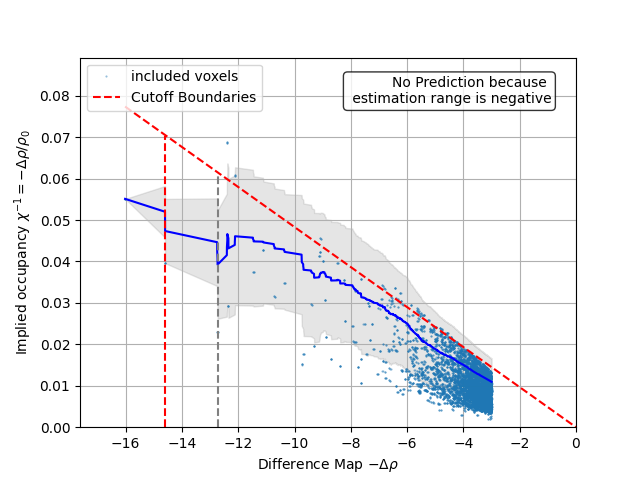

In [16]:
# plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask, config)




TypeError: gemmi_structure_to_calculated_map() missing 1 required keyword-only argument: 'map_sampling'

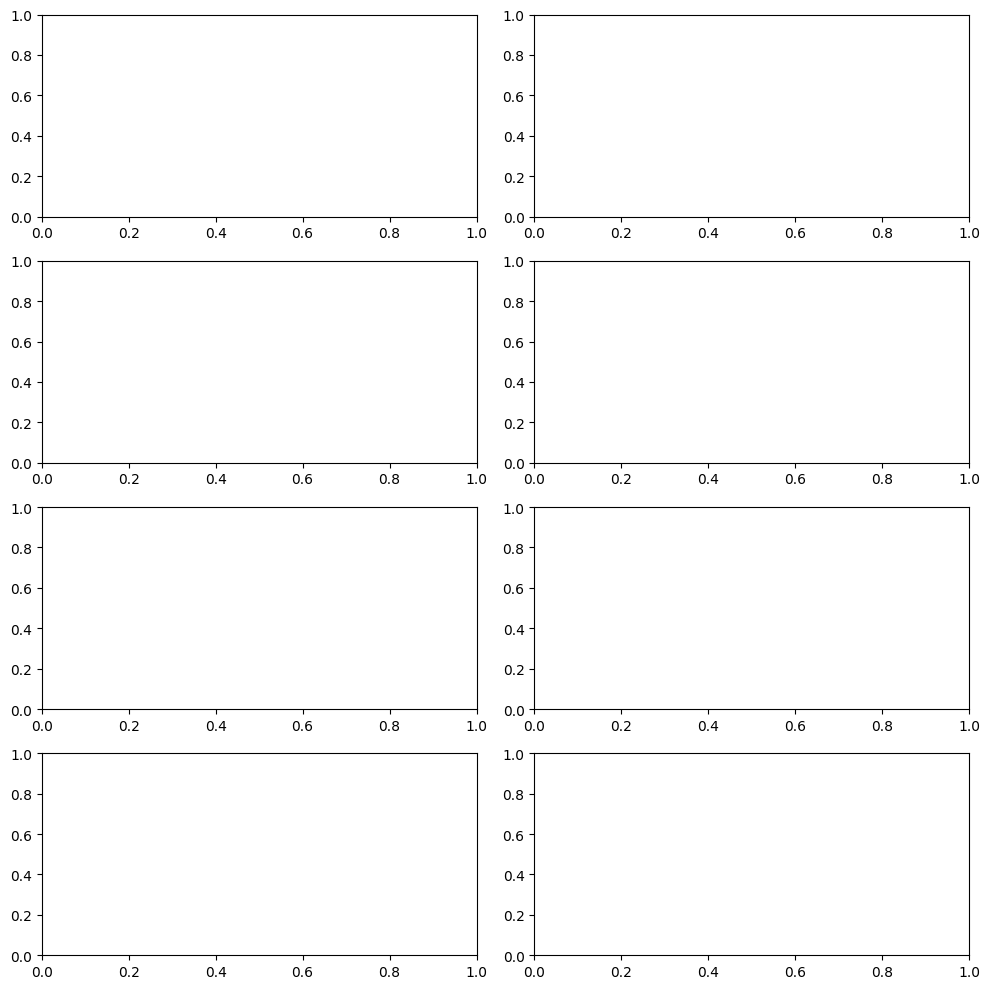

In [17]:
plt.close("all")
%matplotlib inline
config_list = get_all_configs()
cols = 2
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
fig, axs = plt.subplots(**kwargs)
# fig, axs_old = plt.subplots(**kwargs)
for ax, config in zip(axs.flatten(),  config_list):
    config["plot"]["set_ylim"] = ((0, 0.2))
    config["masking"]["dark_size_threshold"]=-0.4
    # config["map_processing"]["diffmap_type"]="kweighted"
    config["plot"]["is_composite"] = True

    if "ECH" in config['general']['name_human']:
        print("changed plot")
        config["plot"]["set_ylim"] = ((0, 0.3))
    # try:
    loader(config, ax)
    # except ValueError:
    #     file_name = config['general']['name_human']
    #     logger.error(f"Error processing config: {file_name}")
    #     ax.set_title(f"{file_name} - Error")
for ax in axs[-1]:
    ax.set_xlabel("Difference Map (RMSD)")
for ax in axs[:,0]:
    ax.set_ylabel("Extrapolation Factor")

from configuration import load_figurepath
loc = load_figurepath()
name_fig = f"overview_real_{config['map_processing']['diffmap_type']}.png"
fileloc = loc+name_fig
fig.savefig(fileloc)
print("Saved to", fileloc)
plt.show()



2026-03-06 10:49:54,434: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:40)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/2_3ps/3ps_deposit.mtz


2026-03-06 10:49:55,361: logger: INFO: No recent preprocessed diffmap found at /Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/OCP/diffmap_17.0_vanilla_110.mtz, calculating diffmap... (processing.py:194)
2026-03-06 10:49:55,404: logger: INFO: Diffmap std: 0.011 (processing.py:565)
2026-03-06 10:49:55,405: logger: INFO: diffmap larger voxel count: 0.3100533191068673 (processing.py:566)
2026-03-06 10:49:55,486: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:243)
2026-03-06 10:49:55,498: logger: INFO: Shift value 0.32599 corresponds to zero frequency 174656.375 (processing.py:257)
2026-03-06 10:49:55,523: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:572)
2026-03-06 10:49:55,603: logger: INFO: ignore_mask voxel count: 0.6806459780092593 (processing.py:243)
2026-03-06 10:49:55,621: logger: INFO: Shift value 0.32418 corresponds to zero frequency 173687.547 (processing.py:257)
2026-03-06 10:49:55,643: logger: INFO:

2026-03-06 10:49:55 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-06 10:49:56 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-06 10:49:56 [info     ] Computing difference map.     
2026-03-06 10:49:56 [info     ]   using fixed                  kparameter=0.09
2026-03-06 10:49:56 [info     ] TV denoising with fixed weight weight=0.0046208595874898985
2026-03-06 10:49:59 [info     ] Map TV-denoised with fixed weight final_negentropy=3.97e-02 initial_negentropy=2.11e-03 weight=0.0046208595874898985


2026-03-06 10:49:59,363: logger: INFO: diffmap has uncertainties: True (processing.py:160)
2026-03-06 10:49:59,368: logger: INFO: Saved diffmap to /Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/OCP/diffmap_17.0_tv_110.mtz (processing.py:218)
2026-03-06 10:49:59,369: logger: INFO: Diffmap zero frequency: 0.020343810319900513 (processing.py:609)
2026-03-06 10:49:59,369: logger: WARNING: Diffmap zero frequency: -968.828125 (processing.py:628)
2026-03-06 10:49:59,400: logger: WARNING: Diffmap Mean: -0.001808, Std: 0.004045 (vacuum_plots_many.py:21)
2026-03-06 10:49:59,458: logger: WARNING: Used threshold for posmask: 0.229, found 1791 blobs (masking.py:133)
2026-03-06 10:49:59,463: logger: INFO: Using blobs with more than 14.861925992336731(3 A^3) voxels (masking.py:150)
2026-03-06 10:49:59,463: logger: INFO: Maximum Blob sizes found: 188 (masking.py:151)
2026-03-06 10:49:59,542: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of s

...

2026-03-06 10:50:23,385: logger: INFO: diffmap has uncertainties: True (processing.py:160)
2026-03-06 10:50:23,391: logger: INFO: Saved diffmap to /Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/PL_3ns/diffmap_26.0_tv_110.mtz (processing.py:218)
2026-03-06 10:50:23,392: logger: INFO: Diffmap zero frequency: 0.03444039821624756 (processing.py:609)
2026-03-06 10:50:23,392: logger: WARNING: Diffmap zero frequency: -3278.875 (processing.py:628)
2026-03-06 10:50:23,414: logger: WARNING: Diffmap Mean: -0.002327, Std: 0.002776 (vacuum_plots_many.py:21)
2026-03-06 10:50:23,450: logger: WARNING: Used threshold for posmask: 0.220, found 2033 blobs (masking.py:133)
2026-03-06 10:50:23,454: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-03-06 10:50:23,455: logger: INFO: Maximum Blob sizes found: 145 (masking.py:151)
2026-03-06 10:50:23,689: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of sh

2026-03-06 10:50:26 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-06 10:50:27 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-06 10:50:27 [info     ] Computing difference map.     
2026-03-06 10:50:27 [info     ]   using fixed                  kparameter=0.07
2026-03-06 10:50:27 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-03-06 10:50:29 [info     ] Map TV-denoised with fixed weight final_negentropy=1.44e-01 initial_negentropy=5.15e-03 weight=0.005807665501203384


2026-03-06 10:50:29,928: logger: INFO: diffmap has uncertainties: True (processing.py:160)
2026-03-06 10:50:29,934: logger: INFO: Saved diffmap to /Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/PL_30ns/diffmap_26.0_tv_110.mtz (processing.py:218)
2026-03-06 10:50:29,935: logger: INFO: Diffmap zero frequency: 0.08580231666564941 (processing.py:609)
2026-03-06 10:50:29,936: logger: WARNING: Diffmap zero frequency: -2376.3125 (processing.py:628)
2026-03-06 10:50:29,960: logger: WARNING: Diffmap Mean: -0.001686, Std: 0.003178 (vacuum_plots_many.py:21)
2026-03-06 10:50:30,003: logger: WARNING: Used threshold for posmask: 0.140, found 1975 blobs (masking.py:133)
2026-03-06 10:50:30,009: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-03-06 10:50:30,010: logger: INFO: Maximum Blob sizes found: 398 (masking.py:151)
2026-03-06 10:50:30,331: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of 

2026-03-06 10:50:33 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-06 10:50:33 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-06 10:50:33 [info     ] Computing difference map.     
2026-03-06 10:50:33 [info     ]   using fixed                  kparameter=0.08
2026-03-06 10:50:33 [info     ] TV denoising with fixed weight weight=0.0032641099320169192
2026-03-06 10:50:36 [info     ] Map TV-denoised with fixed weight final_negentropy=4.93e-02 initial_negentropy=5.20e-04 weight=0.0032641099320169192


2026-03-06 10:50:36,401: logger: INFO: diffmap has uncertainties: True (processing.py:160)
2026-03-06 10:50:36,408: logger: INFO: Saved diffmap to /Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/PL_3ps/diffmap_26.0_tv_110.mtz (processing.py:218)
2026-03-06 10:50:36,409: logger: INFO: Diffmap zero frequency: 0.041776180267333984 (processing.py:609)
2026-03-06 10:50:36,410: logger: WARNING: Diffmap zero frequency: 2116.8125 (processing.py:628)
2026-03-06 10:50:36,434: logger: WARNING: Diffmap Mean: 0.001502, Std: 0.002026 (vacuum_plots_many.py:21)
2026-03-06 10:50:36,476: logger: WARNING: Used threshold for posmask: 0.187, found 1766 blobs (masking.py:133)
2026-03-06 10:50:36,481: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-03-06 10:50:36,481: logger: INFO: Maximum Blob sizes found: 270 (masking.py:151)
2026-03-06 10:50:36,755: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of sh

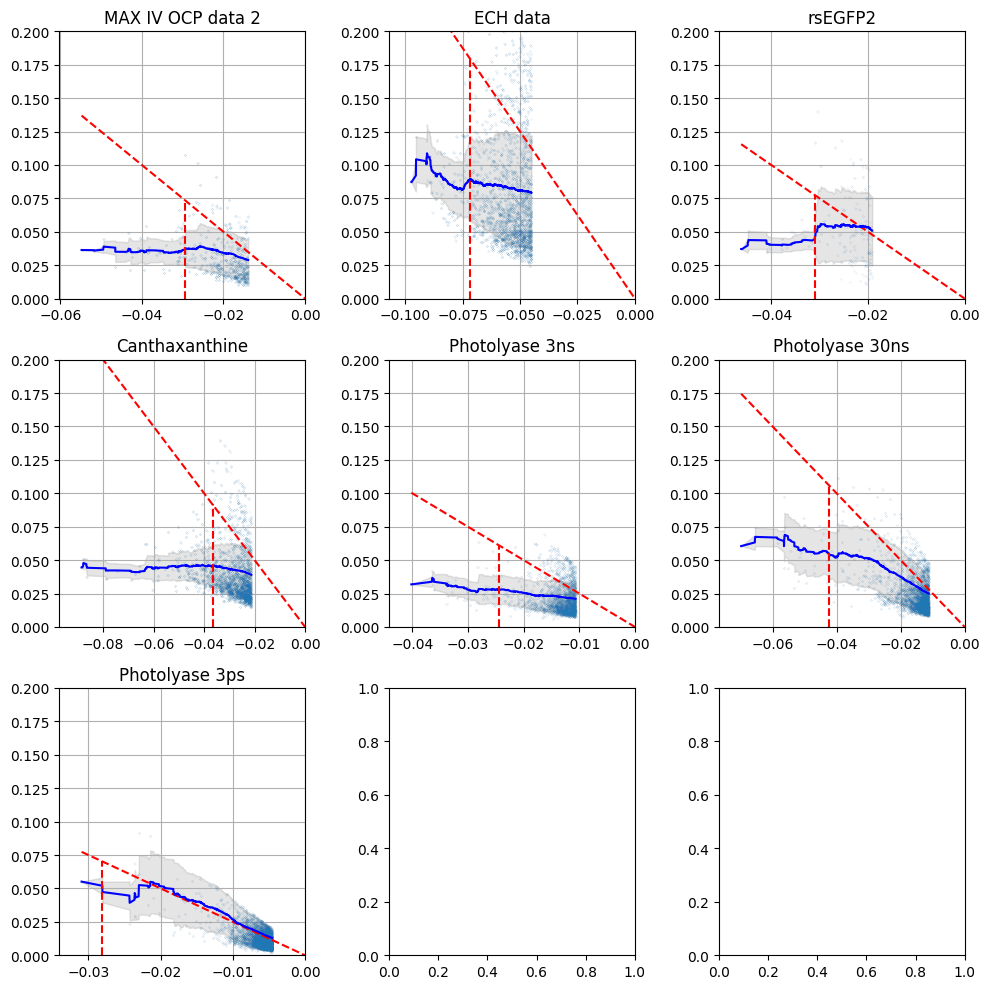

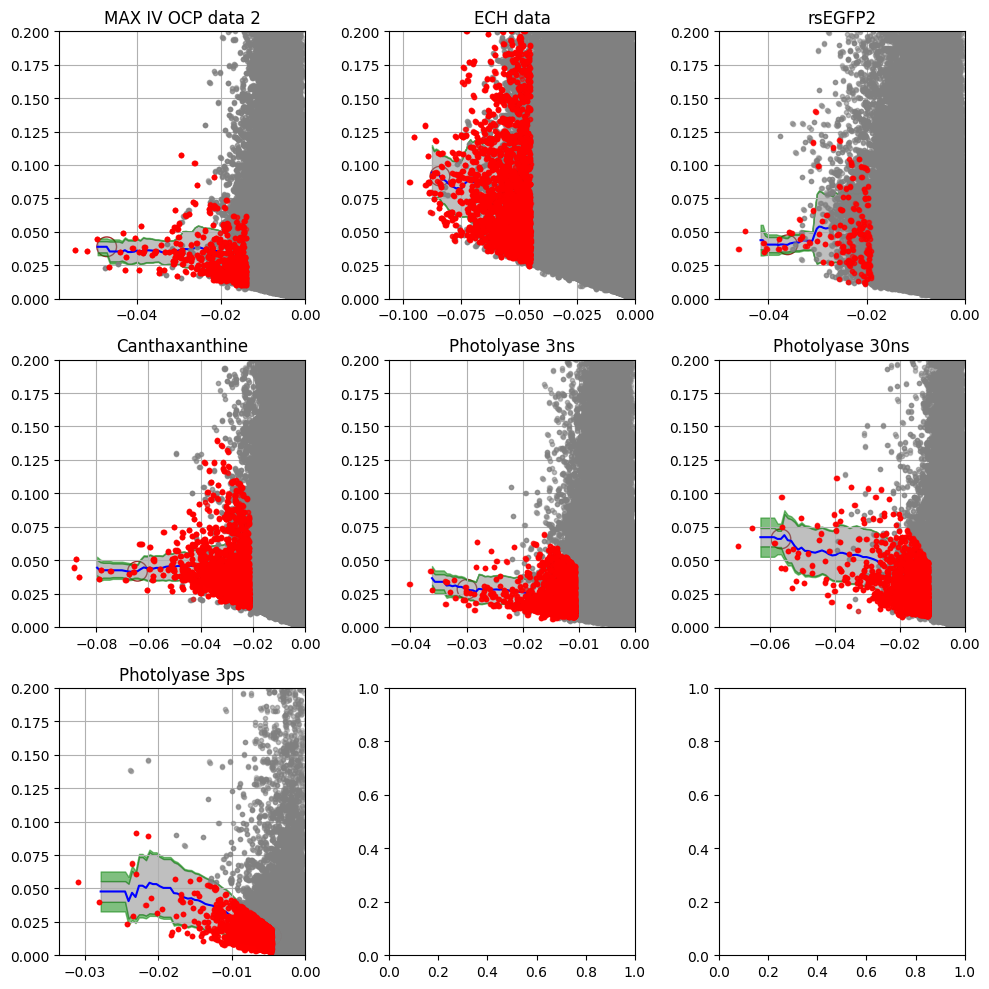

In [ ]:
config_list = get_all_configs()
cols = 3
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
fig, axs = plt.subplots(**kwargs)
fig, axs_old = plt.subplots(**kwargs)
for ax,ax_old, config in zip(axs.flatten(), axs_old.flatten(), config_list):
    config["plot"]["set_ylim"] = ((0, 0.2))
    config["plot"]["is_composite"] = True
    config["plot"]["markersize"] = 0.1
    config["masking"]["dark_size_threshold"]=-0.4

    loader_double(config, ax, ax_old)
plt.show()


2026-03-04 17:44:04,475: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:40)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz


2026-03-04 17:44:05,875: logger: INFO: Loading preprocessed maps from OCP/OCP/diffmap_17.0_tv_110.mtz (processing.py:190)
2026-03-04 17:44:05,988: logger: INFO: Diffmap std: 0.004 (processing.py:565)
2026-03-04 17:44:05,989: logger: INFO: diffmap larger voxel count: 0.2588350272472994 (processing.py:566)
2026-03-04 17:44:06,101: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:243)
2026-03-04 17:44:06,117: logger: INFO: Shift value 0.33421 corresponds to zero frequency 179062.328 (processing.py:257)
2026-03-04 17:44:06,151: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:572)
2026-03-04 17:44:06,266: logger: INFO: ignore_mask voxel count: 0.6714583031925154 (processing.py:243)
2026-03-04 17:44:06,284: logger: INFO: Shift value 0.32728 corresponds to zero frequency 175345.906 (processing.py:257)
2026-03-04 17:44:06,318: logger: INFO: calculating autoshift for triggered map... done (processing.py:576)
2026-03-04 17:44:06,319

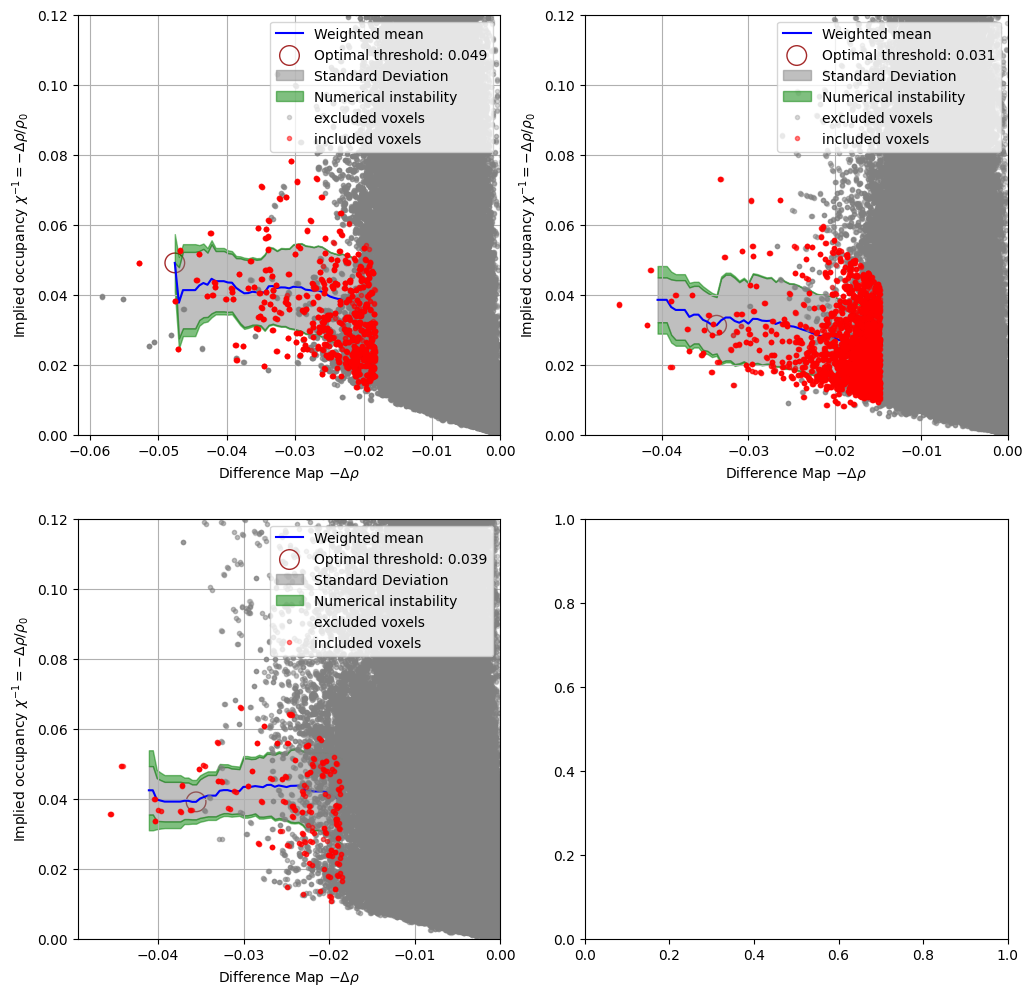

In [ ]:

config_list = get_some_configs()
leng = len(config_list)//2+len(config_list)%2
fig, axs = plt.subplots(leng,2, figsize=(12, 6*leng))
for ax, config in zip(axs.flatten(), config_list):
    config["plot"]["set_ylim"] = ((0, 0.12))
    loader(config, ax)
plt.show()